# 51 — LSEG/Gemma hybrid implementation capacity

**Candidate framing:** LSEG/Gemma semantic event selection with FinBERT
cross-sectional ranking, tested as an implementation diagnostic without pooling
LSEG and FNSPID.

Notebook 36's leading same-window hybrid is unchanged: Gemma determines exact-event
dates and long/short counts, FinBERT ranks the immutable original 33, positions are
capped at 25%, held for one complete open-to-open session, and charged 10 bps per
traded side. This notebook asks a narrower question: how much capital could that
already frozen book plausibly absorb once its drift-adjusted orders are charged an
additional size-dependent market-impact cost?

The assumptions were frozen in
`frozen_specs/lseg_gemma_hybrid_capacity_v1.json` before the capacity curve was
calculated. This is an opened-window implementation audit, not new alpha evidence.
Licensed headline text is neither loaded nor persisted.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.capacity import (  # noqa: E402
    ImpactConfig,
    build_lagged_liquidity,
    fold_terminal_liquidation,
    simulate_square_root_impact,
    summarize_capacity,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260813
COST_BPS = 10.0
SINGLE_NAME_CAP = 0.25
LIQUIDITY_WINDOW = 20
LIQUIDITY_MINIMUM_OBSERVATIONS = 5
PARTICIPATION_LIMIT = 0.05
PRIMARY_IMPACT_COEFFICIENT = 1.0
IMPACT_COEFFICIENTS = (0.5, 1.0)
AUM_GRID = (
    1_000_000.0,
    2_000_000.0,
    5_000_000.0,
    10_000_000.0,
    25_000_000.0,
    50_000_000.0,
    100_000_000.0,
    250_000_000.0,
    500_000_000.0,
    1_000_000_000.0,
)
REFERENCE_AUM = (1_000_000.0, 10_000_000.0)
IDENTITY_TOLERANCE = 1e-12

AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
GEMMA_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
FINBERT_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
NOTEBOOK36_DIR = REPO_ROOT / "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit"
NOTEBOOK36_DAILY = NOTEBOOK36_DIR / "capped_hybrid_daily.parquet"
NOTEBOOK36_MANIFEST = NOTEBOOK36_DIR / "manifest.json"
FROZEN_SPEC_PATH = (
    REPO_ROOT / "final_experiments/frozen_specs/lseg_gemma_hybrid_capacity_v1.json"
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Frozen assumptions and point-in-time inputs

The added impact rate for an order of dollar notional $q$ is

$$Y\,\sigma_{20,t-1}\sqrt{q/ADV_{20,t-1}},$$

charged on the order notional in addition to the fixed 10 bps per side. The
primary coefficient is conservatively set to $Y=1$ and $Y=0.5$ is reported as a
sensitivity, not selected from the outcomes. The square-root shape is motivated by
large institutional-equity execution studies such as
[Bucci et al. (2019)](https://arxiv.org/abs/1811.05230) and
[Said et al. (2021)](https://arxiv.org/abs/1905.04569); broader scale and trading-cost
evidence is discussed by [Kyle and Obizhaeva](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3124502)
and [Frazzini, Israel, and Moskowitz](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3229719).

`ADV` is the rolling mean of past close times reported volume. Volatility is the
rolling standard deviation of past open-to-open returns. Both are shifted one full
session. A 5% full-day-ADV ceiling is a hard feasibility condition. Because the
strategy is specified for the open, full-day ADV is optimistic: the resulting
capacity is an upper bound, not an executable open-auction quotation.

In [2]:
frozen_spec = json.loads(FROZEN_SPEC_PATH.read_text())
assert frozen_spec["status"] == "frozen_before_capacity_outcomes"
assert frozen_spec["initial_aum_usd_grid"] == [int(value) for value in AUM_GRID]
assert frozen_spec["impact_model"]["primary_coefficient_Y"] == PRIMARY_IMPACT_COEFFICIENT
assert frozen_spec["impact_model"]["sensitivity_coefficients_Y"] == [0.5]
assert frozen_spec["impact_model"]["hard_participation_ceiling"] == PARTICIPATION_LIMIT

sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
gemma = gemma.loc[gemma["symbol"].isin(original_symbols)].copy()
finbert = finbert.loc[finbert["symbol"].isin(original_symbols)].copy()
if not gemma[["session_date", "symbol"]].equals(finbert[["session_date", "symbol"]]):
    raise ValueError("paired scorer panels are not row-aligned")
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate scorer rows")
if finbert["strongest_event"].isna().any():
    raise ValueError("FinBERT ranks must be complete")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
liquidity = build_lagged_liquidity(
    prices.loc[prices["symbol"].isin(original_symbols)].copy(),
    window_sessions=LIQUIDITY_WINDOW,
    minimum_observations=LIQUIDITY_MINIMUM_OBSERVATIONS,
)
open_wide = (
    prices.loc[prices["symbol"].isin(original_symbols)]
    .pivot(index="session_date", columns="symbol", values="open")
    .sort_index()
    .dropna()
)
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(sessions) != 167 or set(symbols) != set(original_symbols):
    raise ValueError("expected 167 sessions and immutable original 33")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no next open")


def rank_map(
    frame: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(
                ["strongest_event", "symbol"],
                ascending=[False, True],
                kind="mergesort",
            )["symbol"]
        )
        for session, day in frame.groupby("session_date", sort=True)
    }
    expected = set(ordered_symbols)
    if len(result) != len(sessions) or any(set(row) != expected for row in result.values()):
        raise ValueError("rank map is incomplete or has the wrong universe")
    return result


def build_hybrid_targets(
    gemma_panel: pd.DataFrame,
    finbert_panel: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> tuple[tuple[TargetPortfolio, ...], pd.DataFrame]:
    _, audit = build_exact_extrema_targets(
        gemma_panel,
        single_name_cap=SINGLE_NAME_CAP,
    )
    ranks = rank_map(finbert_panel, ordered_symbols)
    targets: list[TargetPortfolio] = []
    for row in audit.itertuples(index=False):
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        ranked = ranks[pd.Timestamp(row.session_date)]
        long_symbols = set(ranked[:n_long]) if eligible else set()
        short_symbols = set(ranked[-n_short:]) if eligible else set()
        if eligible and (not n_long or not n_short or long_symbols & short_symbols):
            raise RuntimeError("invalid hybrid rank selection")
        leg_exposure = (
            min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
            if eligible
            else 0.0
        )
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in ordered_symbols
        }
        vector = np.asarray([weights[symbol] for symbol in ordered_symbols], dtype=float)
        if abs(vector.sum()) > 1e-12 or np.abs(vector).max() > SINGLE_NAME_CAP + 1e-12:
            raise RuntimeError("hybrid target violates exposure constraints")
        positions = tuple(
            PositionTarget(
                symbol=symbol,
                action=float(np.sign(weights[symbol])),
                volatility=None,
                raw_weight=weights[symbol],
                target_weight=weights[symbol],
                exclusion_reason=None,
            )
            for symbol in ordered_symbols
        )
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(row.session_date).date()),
                positions=positions,
                gross_exposure=float(np.abs(vector).sum()),
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
    return tuple(targets), audit


hybrid_targets, target_audit = build_hybrid_targets(gemma, finbert, symbols)
return_rows: list[OpenToOpenReturn] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )

input_summary = pd.DataFrame(
    [
        {
            "sessions": len(sessions),
            "companies": len(symbols),
            "active_sessions": int(target_audit["eligible"].sum()),
            "price_rows": len(prices),
            "liquidity_rows": len(liquidity),
            "liquidity_start": liquidity["session_date"].min(),
            "liquidity_end": liquidity["session_date"].max(),
            "licensed_headline_text_loaded": False,
            "source_regimes_pooled": False,
        }
    ]
)
display(input_summary.T)

,0
sessions,167
companies,33
active_sessions,70
price_rows,5779
liquidity_rows,5779
liquidity_start,2025-10-20 00:00:00
liquidity_end,2026-07-02 00:00:00
licensed_headline_text_loaded,False
source_regimes_pooled,False


## Accounting identity and liquidity coverage

Before adding impact, the new replay must reproduce both the core drift-aware ledger
and Notebook 36. This catches changes in current-weight drift, cost convention, final
liquidation, target timing, or return alignment. The same zero-impact order audit is
also used to verify that every trade has valid lagged liquidity.

In [3]:
core_full = ledger_rows_to_frame(
    run_open_to_open_ledger(
        hybrid_targets,
        return_rows,
        cost_rate_per_side=COST_BPS / 10_000.0,
        initial_nav_usd=1_000_000.0,
        force_final_liquidation=True,
    )
)


def fold_core_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


core_daily = fold_core_liquidation(core_full)
zero_impact = simulate_square_root_impact(
    hybrid_targets,
    return_rows,
    liquidity,
    config=ImpactConfig(
        fixed_cost_rate_per_side=COST_BPS / 10_000.0,
        impact_coefficient=0.0,
        initial_nav_usd=1_000_000.0,
        participation_limit=PARTICIPATION_LIMIT,
    ),
)
zero_daily = fold_terminal_liquidation(zero_impact.daily)
notebook36_daily = pd.read_parquet(NOTEBOOK36_DAILY).reset_index(drop=True)

identity_rows = []
for metric, capacity_column, core_column in (
    ("gross_return", "gross_return", "gross_return"),
    ("fixed_cost", "fixed_cost", "cost"),
    ("turnover", "turnover", "turnover"),
    ("net_return", "net_return", "net_return"),
    ("start_nav", "start_nav", "start_nav"),
    ("end_nav", "end_nav", "end_nav"),
):
    capacity_values = zero_daily[capacity_column].to_numpy(dtype=float)
    core_values = core_daily[core_column].to_numpy(dtype=float)
    notebook36_values = notebook36_daily[core_column].to_numpy(dtype=float)
    identity_rows.append(
        {
            "metric": metric,
            "maximum_error_vs_core": float(np.max(np.abs(capacity_values - core_values))),
            "maximum_error_vs_notebook36": float(
                np.max(np.abs(capacity_values - notebook36_values))
            ),
        }
    )
identity = pd.DataFrame(identity_rows)
zero_impact_identity_gate = bool(
    identity[["maximum_error_vs_core", "maximum_error_vs_notebook36"]]
    .to_numpy(dtype=float)
    .max()
    <= IDENTITY_TOLERANCE
)
liquidity_coverage_gate = bool(
    np.isfinite(zero_impact.orders[["adv20_usd", "sigma20"]].to_numpy(dtype=float)).all()
    and zero_impact.orders["adv20_usd"].gt(0).all()
    and zero_impact.orders["sigma20"].ge(0).all()
)
liquidity_audit = pd.DataFrame(
    [
        {
            "nonzero_orders": len(zero_impact.orders),
            "rebalance_orders": int((~zero_impact.orders["final_liquidation"]).sum()),
            "liquidation_orders": int(zero_impact.orders["final_liquidation"].sum()),
            "minimum_adv20_usd": float(zero_impact.orders["adv20_usd"].min()),
            "median_adv20_usd": float(zero_impact.orders["adv20_usd"].median()),
            "minimum_sigma20": float(zero_impact.orders["sigma20"].min()),
            "median_sigma20": float(zero_impact.orders["sigma20"].median()),
            "zero_impact_identity_gate": zero_impact_identity_gate,
            "liquidity_coverage_gate": liquidity_coverage_gate,
        }
    ]
)
display(identity)
display(liquidity_audit.T)
if not (zero_impact_identity_gate and liquidity_coverage_gate):
    raise RuntimeError("capacity input/accounting gate failed")

,metric,maximum_error_vs_core,maximum_error_vs_notebook36
0,gross_return,0.000000,0.000000
1,fixed_cost,0.000000,0.000000
2,turnover,0.000000,0.000000
3,net_return,0.000000,0.000000
4,start_nav,0.000000,0.000000
5,end_nav,0.000000,0.000000


,0
nonzero_orders,419
rebalance_orders,419
liquidation_orders,0
minimum_adv20_usd,"108,265,650.001250"
median_adv20_usd,"448,555,184.747000"
minimum_sigma20,0.006990
median_sigma20,0.017899
zero_impact_identity_gate,True
liquidity_coverage_gate,True


## Predeclared AUM stress

Every row below replays the same targets and returns. AUM changes only trade dollars,
participation, impact, subsequent NAV, and the drifted weights that must be rebalanced.
The reported capacity is the largest **predeclared grid point** under primary $Y=1$
that retains positive total net return, positive net Sharpe, and no individual order
above 5% of lagged full-day ADV. No interpolation or post-outcome threshold selection
is used.

In [4]:
curve_rows: list[dict[str, object]] = []
reference_simulations: dict[tuple[float, float], object] = {}
for coefficient in IMPACT_COEFFICIENTS:
    for initial_aum in AUM_GRID:
        simulation = simulate_square_root_impact(
            hybrid_targets,
            return_rows,
            liquidity,
            config=ImpactConfig(
                fixed_cost_rate_per_side=COST_BPS / 10_000.0,
                impact_coefficient=coefficient,
                initial_nav_usd=initial_aum,
                participation_limit=PARTICIPATION_LIMIT,
            ),
        )
        metrics = summarize_capacity(
            simulation,
            participation_limit=PARTICIPATION_LIMIT,
        )
        curve_rows.append(
            {
                "impact_coefficient": coefficient,
                "initial_aum_usd": initial_aum,
                **metrics,
            }
        )
        if initial_aum in REFERENCE_AUM:
            reference_simulations[(coefficient, initial_aum)] = simulation

capacity_curve = pd.DataFrame(curve_rows)
capacity_curve["positive_after_impact"] = (
    capacity_curve["total_return_net"].gt(0) & capacity_curve["sharpe_net"].gt(0)
)
capacity_curve["capacity_gate_at_grid_point"] = (
    capacity_curve["positive_after_impact"]
    & capacity_curve["all_orders_within_participation_limit"]
)
primary_curve = capacity_curve.loc[
    capacity_curve["impact_coefficient"].eq(PRIMARY_IMPACT_COEFFICIENT)
].copy()
eligible_grid = primary_curve.loc[primary_curve["capacity_gate_at_grid_point"], "initial_aum_usd"]
capacity_aum_usd = float(eligible_grid.max()) if len(eligible_grid) else float("nan")
reference_results = capacity_curve.loc[
    capacity_curve["initial_aum_usd"].isin(REFERENCE_AUM)
].reset_index(drop=True)

display(
    capacity_curve[
        [
            "impact_coefficient",
            "initial_aum_usd",
            "sharpe_net",
            "total_return_net",
            "mean_impact_bps_per_traded_dollar",
            "p95_participation",
            "maximum_participation",
            "orders_over_participation_limit",
            "capacity_gate_at_grid_point",
        ]
    ]
)
display(reference_results.T)

,impact_coefficient,initial_aum_usd,sharpe_net,total_return_net,mean_impact_bps_per_traded_dollar,p95_participation,maximum_participation,orders_over_participation_limit,capacity_gate_at_grid_point
0,0.500000,"1,000,000.000000",1.975186,0.101568,2.014821,0.001538,0.002450,0,True
1,0.500000,"2,000,000.000000",1.852643,0.094794,2.844841,0.003063,0.004877,0,True
2,0.500000,"5,000,000.000000",1.609773,0.081533,4.483944,0.007575,0.012075,0,True
3,0.500000,"10,000,000.000000",1.336714,0.066867,6.318975,0.014962,0.023892,0,True
4,0.500000,"25,000,000.000000",0.798071,0.038615,9.922563,0.036503,0.058475,12,False
5,0.500000,"50,000,000.000000",0.198290,0.008066,13.926059,0.071046,0.114213,53,False
6,0.500000,"100,000,000.000000",-0.631543,-0.032942,19.488121,0.137354,0.220999,174,False
7,0.500000,"250,000,000.000000",-2.190723,-0.107398,30.200914,0.337028,0.525896,268,False
8,0.500000,"500,000,000.000000",-3.773259,-0.181669,41.805629,0.665162,1.047720,320,False
9,0.500000,"1,000,000,000.000000",-5.662070,-0.272157,57.472938,1.243021,2.085826,333,False


,0,1,2,3
impact_coefficient,0.500000,0.500000,1.000000,1.000000
initial_aum_usd,"1,000,000.000000","10,000,000.000000","1,000,000.000000","10,000,000.000000"
n_sessions,167,167,167,167
active_sessions,70,70,70,70
n_orders,419,419,419,419
sharpe_gross,3.699940,3.699940,3.699940,3.699940
sharpe_net,1.975186,1.336714,1.679489,0.413421
total_return_gross,0.204584,0.204584,0.204584,0.204584
total_return_net,0.101568,0.066867,0.085318,0.018924
maximum_drawdown,-0.031656,-0.042897,-0.035783,-0.065019


In [5]:
primary_one_million = primary_curve.set_index("initial_aum_usd").loc[1_000_000.0]
primary_ten_million = primary_curve.set_index("initial_aum_usd").loc[10_000_000.0]
gates = pd.DataFrame(
    [
        {
            "zero_impact_identity_gate": zero_impact_identity_gate,
            "liquidity_coverage_gate": liquidity_coverage_gate,
            "one_million_positive_after_impact": bool(
                primary_one_million["positive_after_impact"]
            ),
            "one_million_all_orders_within_5pct_adv": bool(
                primary_one_million["all_orders_within_participation_limit"]
            ),
            "ten_million_positive_after_impact": bool(
                primary_ten_million["positive_after_impact"]
            ),
            "ten_million_all_orders_within_5pct_adv": bool(
                primary_ten_million["all_orders_within_participation_limit"]
            ),
            "capacity_grid_has_feasible_point": bool(len(eligible_grid)),
            "capacity_aum_usd_primary_grid": capacity_aum_usd,
            "one_million_net_sharpe": float(primary_one_million["sharpe_net"]),
            "one_million_total_net_return": float(
                primary_one_million["total_return_net"]
            ),
            "one_million_maximum_participation": float(
                primary_one_million["maximum_participation"]
            ),
            "ten_million_net_sharpe": float(primary_ten_million["sharpe_net"]),
            "ten_million_total_net_return": float(
                primary_ten_million["total_return_net"]
            ),
            "ten_million_maximum_participation": float(
                primary_ten_million["maximum_participation"]
            ),
            "promotion_gate": False,
        }
    ]
)
display(gates.T)

,0
zero_impact_identity_gate,True
liquidity_coverage_gate,True
one_million_positive_after_impact,True
one_million_all_orders_within_5pct_adv,True
ten_million_positive_after_impact,True
ten_million_all_orders_within_5pct_adv,True
capacity_grid_has_feasible_point,True
capacity_aum_usd_primary_grid,"10,000,000.000000"
one_million_net_sharpe,1.679489
one_million_total_net_return,0.085318


In [6]:
failed_grid = primary_curve.loc[~primary_curve["capacity_gate_at_grid_point"]]
first_failed_aum_usd = (
    float(failed_grid["initial_aum_usd"].min()) if len(failed_grid) else float("nan")
)
first_failed_simulation = simulate_square_root_impact(
    hybrid_targets,
    return_rows,
    liquidity,
    config=ImpactConfig(
        fixed_cost_rate_per_side=COST_BPS / 10_000.0,
        impact_coefficient=PRIMARY_IMPACT_COEFFICIENT,
        initial_nav_usd=first_failed_aum_usd,
        participation_limit=PARTICIPATION_LIMIT,
    ),
)
first_failed_orders = first_failed_simulation.orders.copy()
breach_orders = first_failed_orders.loc[
    first_failed_orders["participation_breach"]
].sort_values("participation", ascending=False, ignore_index=True)
bottleneck_symbols = (
    first_failed_orders.groupby("symbol", as_index=False)
    .agg(
        n_orders=("symbol", "size"),
        participation_breaches=("participation_breach", "sum"),
        maximum_participation=("participation", "max"),
        p95_participation=("participation", lambda values: values.quantile(0.95)),
        total_trade_notional_usd=("trade_notional_usd", "sum"),
        total_impact_cost_usd=("impact_cost_usd", "sum"),
    )
    .sort_values(
        ["participation_breaches", "maximum_participation"],
        ascending=False,
        ignore_index=True,
    )
)
display(
    pd.DataFrame(
        [
            {
                "first_failed_aum_usd": first_failed_aum_usd,
                "breaching_orders": len(breach_orders),
                "breaching_symbols": int(breach_orders["symbol"].nunique()),
                "maximum_participation": float(first_failed_orders["participation"].max()),
            }
        ]
    ).T
)
display(bottleneck_symbols.head(10))
display(
    breach_orders[
        [
            "session_date",
            "symbol",
            "trade_notional_usd",
            "adv20_usd",
            "sigma20",
            "participation",
            "impact_rate",
        ]
    ]
)

,0
first_failed_aum_usd,"25,000,000.000000"
breaching_orders,10.000000
breaching_symbols,2.000000
maximum_participation,0.055250


,symbol,n_orders,participation_breaches,maximum_participation,p95_participation,total_trade_notional_usd,total_impact_cost_usd
0,DUK,17,8,0.055250,0.055173,"74,199,100.089434","148,736.736928"
1,PLD,25,2,0.052626,0.048659,"92,657,641.578935","181,023.246819"
2,SO,19,0,0.047894,0.047573,"70,649,218.586005","144,559.187088"
3,FCX,28,0,0.043206,0.039034,"131,618,851.551366","681,561.218220"
4,AMT,13,0,0.037261,0.037232,"34,257,802.177476","83,582.999117"
5,NEE,2,0,0.034555,0.034509,"12,522,719.221160","46,650.843750"
6,NEM,12,0,0.027440,0.026868,"57,866,381.095113","265,376.033838"
7,COP,22,0,0.026227,0.025935,"79,387,419.245211","235,808.979380"
8,BA,15,0,0.023361,0.022557,"70,305,649.990119","185,448.478817"
9,HD,8,0,0.020830,0.020721,"50,747,818.888256","107,660.217645"


,session_date,symbol,trade_notional_usd,adv20_usd,sigma20,participation,impact_rate
0,2026-05-26,DUK,"6,395,080.249799","115,748,642.535000",0.009755,0.055250,0.002293
1,2026-05-22,DUK,"6,344,204.511933","115,028,522.471500",0.009960,0.055153,0.002339
2,2026-06-08,DUK,"6,268,105.976248","117,452,690.220500",0.009323,0.053367,0.002154
3,2025-11-21,DUK,"6,215,576.815444","117,784,217.807500",0.008311,0.052771,0.001909
4,2025-11-20,DUK,"6,182,208.662701","117,354,361.810500",0.008503,0.052680,0.001952
5,2025-11-18,PLD,"6,182,450.481698","117,479,411.536500",0.007181,0.052626,0.001647
6,2026-06-09,DUK,"6,193,214.583297","118,768,230.709000",0.009656,0.052145,0.002205
7,2026-06-10,DUK,"6,207,312.749921","119,182,650.427000",0.009945,0.052082,0.002270
8,2026-06-12,DUK,"6,156,274.170114","118,255,352.750500",0.010948,0.052059,0.002498
9,2025-11-19,PLD,"6,207,521.246020","120,267,691.710000",0.006990,0.051614,0.001588


## Capacity curves and the reference implementations

The first figure separates economic erosion (Sharpe and total net return) from the
hard trading constraint (maximum participation). Points to the right of a 5% breach
remain stress-test extrapolations of the square-root curve, not executable capacity.
The second figure shows how the primary $Y=1$ impact charge changes the realised net
wealth path at the frozen $1m and $10m reference sizes.

findfont: Failed to find font weight medium, now using 400.


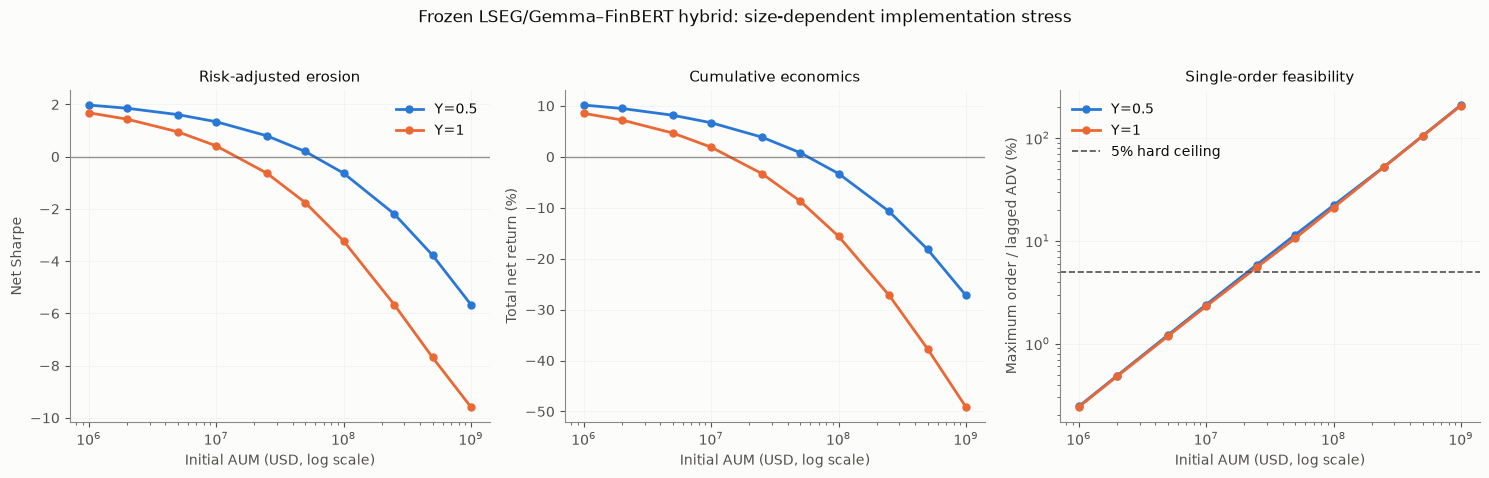

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for index, (coefficient, group) in enumerate(capacity_curve.groupby("impact_coefficient")):
    group = group.sort_values("initial_aum_usd")
    color = CATEGORICAL[index]
    label = f"Y={coefficient:g}"
    axes[0].plot(group["initial_aum_usd"], group["sharpe_net"], marker="o", label=label, color=color)
    axes[1].plot(
        group["initial_aum_usd"],
        100.0 * group["total_return_net"],
        marker="o",
        label=label,
        color=color,
    )
    axes[2].plot(
        group["initial_aum_usd"],
        100.0 * group["maximum_participation"],
        marker="o",
        label=label,
        color=color,
    )
for axis in axes:
    axis.set_xscale("log")
    axis.set_xlabel("Initial AUM (USD, log scale)")
    axis.grid(True, which="major", alpha=0.2)
axes[0].axhline(0.0, color=INK["reference"], linewidth=1, alpha=0.6)
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Risk-adjusted erosion")
axes[1].axhline(0.0, color=INK["reference"], linewidth=1, alpha=0.6)
axes[1].set_ylabel("Total net return (%)")
axes[1].set_title("Cumulative economics")
axes[2].axhline(
    100.0 * PARTICIPATION_LIMIT,
    color=INK["reference"],
    linewidth=1.2,
    linestyle="--",
    label="5% hard ceiling",
)
axes[2].set_ylabel("Maximum order / lagged ADV (%)")
axes[2].set_title("Single-order feasibility")
axes[2].set_yscale("log")
axes[0].legend(frameon=False)
axes[2].legend(frameon=False)
fig.suptitle("Frozen LSEG/Gemma–FinBERT hybrid: size-dependent implementation stress", y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "capacity_curves.png", dpi=180, bbox_inches="tight")
plt.show()

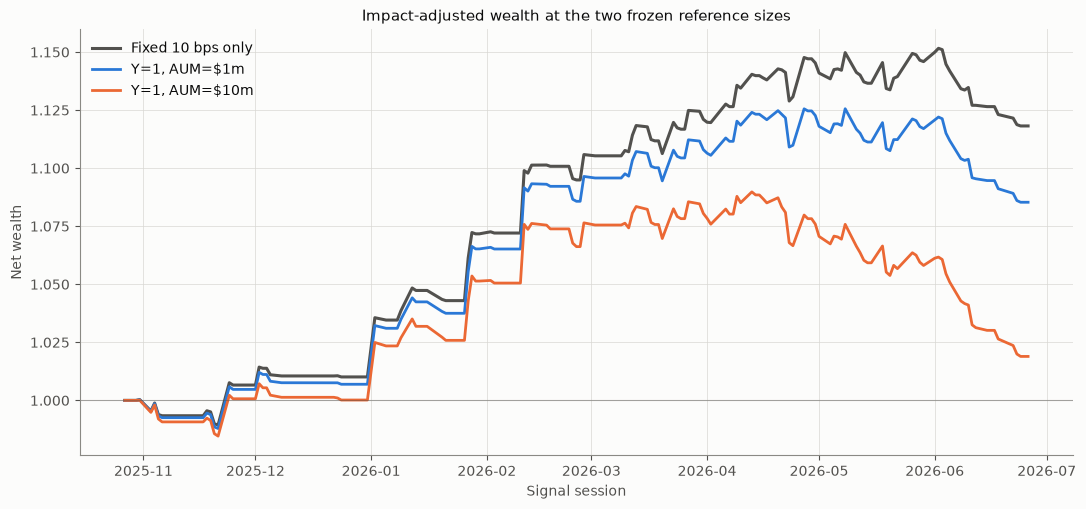

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.2))
base_wealth = (1.0 + core_daily["net_return"]).cumprod()
ax.plot(
    core_daily["session_date"],
    base_wealth,
    color=INK["reference"],
    linewidth=2.2,
    label="Fixed 10 bps only",
)
for index, initial_aum in enumerate(REFERENCE_AUM):
    simulation = reference_simulations[(PRIMARY_IMPACT_COEFFICIENT, initial_aum)]
    daily = fold_terminal_liquidation(simulation.daily)
    wealth = (1.0 + daily["net_return"]).cumprod()
    ax.plot(
        daily["session_date"],
        wealth,
        linewidth=2,
        color=CATEGORICAL[index],
        label=f"Y=1, AUM=${initial_aum / 1_000_000:g}m",
    )
ax.axhline(1.0, color=INK["reference"], linewidth=0.8, alpha=0.45)
ax.set_xlabel("Signal session")
ax.set_ylabel("Net wealth")
ax.set_title("Impact-adjusted wealth at the two frozen reference sizes")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "reference_aum_equity.png", dpi=180, bbox_inches="tight")
plt.show()

## Persisted aggregate evidence

Only aggregate or market-derived diagnostics are written. No headline text or
proprietary story payload is included. The output directory remains gitignored;
the executed notebook is the source-controlled result surface.

In [9]:
input_summary.to_csv(OUTPUT_DIR / "input_summary.csv", index=False)
target_audit.to_csv(OUTPUT_DIR / "target_audit.csv", index=False)
liquidity.to_parquet(OUTPUT_DIR / "lagged_liquidity.parquet", index=False)
identity.to_csv(OUTPUT_DIR / "accounting_identity.csv", index=False)
liquidity_audit.to_csv(OUTPUT_DIR / "liquidity_audit.csv", index=False)
capacity_curve.to_csv(OUTPUT_DIR / "capacity_curve.csv", index=False)
reference_results.to_csv(OUTPUT_DIR / "reference_results.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
bottleneck_symbols.to_csv(OUTPUT_DIR / "first_failed_bottleneck_symbols.csv", index=False)
breach_orders.to_csv(OUTPUT_DIR / "first_failed_breach_orders.csv", index=False)
for initial_aum in REFERENCE_AUM:
    simulation = reference_simulations[(PRIMARY_IMPACT_COEFFICIENT, initial_aum)]
    slug = f"{int(initial_aum / 1_000_000)}m"
    fold_terminal_liquidation(simulation.daily).to_parquet(
        OUTPUT_DIR / f"primary_{slug}_daily.parquet", index=False
    )
    simulation.orders.to_parquet(OUTPUT_DIR / f"primary_{slug}_orders.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_CAPACITY_DIAGNOSTIC",
    "notebook": "51_lseg_gemma_hybrid_implementation_capacity.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "notebook36_daily": str(NOTEBOOK36_DAILY.relative_to(REPO_ROOT)),
        "notebook36_manifest": str(NOTEBOOK36_MANIFEST.relative_to(REPO_ROOT)),
        "frozen_spec": str(FROZEN_SPEC_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
        "source_regimes_pooled": False,
    },
    "specification": frozen_spec,
    "input_summary": json.loads(input_summary.to_json(orient="records"))[0],
    "identity": json.loads(identity.to_json(orient="records")),
    "liquidity_audit": json.loads(liquidity_audit.to_json(orient="records"))[0],
    "capacity_curve": json.loads(capacity_curve.to_json(orient="records")),
    "reference_results": json.loads(reference_results.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "first_failed_grid_point": {
        "initial_aum_usd": first_failed_aum_usd,
        "breaching_orders": len(breach_orders),
        "breaching_symbols": int(breach_orders["symbol"].nunique()),
        "maximum_participation": float(first_failed_orders["participation"].max()),
        "bottleneck_symbols": json.loads(
            bottleneck_symbols.head(10).to_json(orient="records")
        ),
    },
    "limitations": [
        "Notebook 36 and its opened outcomes directly motivated this implementation audit",
        "the eight-month LSEG window is not an independent holdout",
        "full-day ADV is optimistic for execution specified at the opening auction",
        "close times reported volume is a coarse historical dollar-volume proxy",
        "the square-root functional form and Y coefficients are scenario assumptions, not estimates from this corpus",
        "impact is extrapolated beyond the 5% participation ceiling only to show stress deterioration",
        "borrow availability, financing, short-sale constraints, taxes, and order-book depth are not modelled",
        "market impact can be state-dependent and correlated across simultaneous orders",
        "human validation of full-corpus Gemma labels remains open",
        "this diagnostic cannot promote the retrospective alpha claim",
        "the frozen prospective post-2026-06-26 evaluation remains required",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_CAPACITY_DIAGNOSTIC",
  "notebook": "51_lseg_gemma_hybrid_implementation_capacity.ipynb",
  "git_commit_at_execution": "1cc66bc7e9a2dc6dc19166e91805c0010e78dd1f",
  "seed": 20260813,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "finbert_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet",
    "price_path": "Data/derived/prices/lseg_us_sector_33_8m.csv",
    "notebook36_daily": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/capped_hybrid_daily.parquet",
    "notebook36_manifest": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/manifest.json",
    "frozen_spec": "final_experiments/frozen_specs/lseg_gemma_hybrid_capacity_v1.json",
    "licensed_headline_text_loaded": false,
    "source_regimes_pooled": false
  },
  "specification": {
    "experiment_

## Interpretation

The useful output is a capacity **bound**, not a better backtest. Under primary
$Y=1$, a $1m book retains net Sharpe 1.68 and +8.53% total return after 10 bps fixed
cost plus estimated impact. The frozen $10m reference remains positive, but only
narrowly: net Sharpe 0.41 and +1.89%, with its largest order at 2.30% of lagged
full-day ADV. The largest predeclared grid point satisfying positive return,
positive Sharpe, and every order below 5% ADV is therefore **$10m**.

At the next point, $25m, net Sharpe is -0.63, total return is -3.29%, and ten orders
breach the participation ceiling. The bottleneck table shows whether those failures
are concentrated in a few repeatedly selected names; it is the right input for a
separately frozen liquidity-aware sizing experiment, not permission to delete the
losing names after observing them.

The bound remains optimistic for open-auction execution and does not alter the
evidential conclusion: the LSEG/Gemma–FinBERT hybrid is the leading same-window
candidate, but it still needs Gate F1 and genuinely new post-2026-06-26 dates before
any alpha claim.